In [53]:
from langchain_ollama import ChatOllama,OllamaLLM
from pydantic import BaseModel, Field
from typing import TypedDict,Literal
from langgraph.graph import StateGraph,START,END

In [23]:
import pandas as pd

In [24]:
data = pd.read_csv('Data/Musical_instruments_reviews.csv')

In [26]:
data.shape

(10261, 9)

In [27]:
top100 = data.head(100)

In [28]:
top100.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A2IBPI20UZIR0U,1384719342,"cassandra tu ""Yeah, well, that's just like, u...","[0, 0]","Not much to write about here, but it does exac...",5.0,good,1393545600,"02 28, 2014"
1,A14VAT5EAX3D9S,1384719342,Jake,"[13, 14]",The product does exactly as it should and is q...,5.0,Jake,1363392000,"03 16, 2013"
2,A195EZSQDW3E21,1384719342,"Rick Bennette ""Rick Bennette""","[1, 1]",The primary job of this device is to block the...,5.0,It Does The Job Well,1377648000,"08 28, 2013"
3,A2C00NNG1ZQQG2,1384719342,"RustyBill ""Sunday Rocker""","[0, 0]",Nice windscreen protects my MXL mic and preven...,5.0,GOOD WINDSCREEN FOR THE MONEY,1392336000,"02 14, 2014"
4,A94QU4C90B1AX,1384719342,SEAN MASLANKA,"[0, 0]",This pop filter is great. It looks and perform...,5.0,No more pops when I record my vocals.,1392940800,"02 21, 2014"


In [75]:
top100['reviewText'][52]

"It hums, crackles, and I think I'm having problems with my equipment.  As soon as I use any of my other cords then the problem is gone.  Hosa makes some other products that have good value.  But based on my experience I don't recommend this one."

In [80]:
class SentimentState(TypedDict):
    review: str
    sentiment: Literal["positive","negative"]
    response: str
    diagnosis: dict
    

In [55]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive","negative"] = Field(description="Get the sentiment of the review.")


class DiagnosisSchema(BaseModel):
    urgency: Literal["High","Medium","Low"] = Field(description="Classify how urgent the issue is in the review.")
    issue_type: str = Field(description="Classify the issue is in the review.")
    tone: str = Field(description="Classify the tone of the customer in the review.")


In [57]:

llm = ChatOllama(
    model="qwen3:8b",
    temperature=0,
)
structured_llm = llm.with_structured_output(SentimentSchema, method="json_schema")


In [58]:
structured_llm2 = llm.with_structured_output(DiagnosisSchema, method="json_schema")

In [30]:
prompt = f"Extract the sentiment based on this review:\n\n{top100['reviewText'][0]}"

In [32]:
response = structured_llm.invoke(prompt)
response.sentiment

'positive'

In [92]:
def calculate_sentiment(state: SentimentState):
    review = state['review']
    prompt = f"Extract the sentiment based on this review:\n\n{review}"

    response = structured_llm.invoke(prompt)
    return {'sentiment':response.sentiment}

def positive_sentiment(state: SentimentState):
    review = state['review']
    prompt = f"Create a warm and single line reply acknowledging and thanking the customer for their review:\n\n{review}"

    response = llm.invoke(prompt)
    return {'response':response.content}

def check_sentiment(state: SentimentState) -> Literal["positive_sentiment","run_diagnosis"]:
    if(state['sentiment']=='positive'):
        return 'positive_sentiment'
    else:
        return 'run_diagnosis'
    
def run_diagnosis(state: SentimentState):
    review = state['review']
    prompt = f"Analyse this review and identify issue type, tone and urgency:\n\n{review}"

    response = structured_llm2.invoke(prompt)
    # print(response.model_dump())
    return {'diagnosis':response.model_dump()}

def negative_sentiment(state: SentimentState):
    review = state['review']
    diagnosis = state['diagnosis']
    
    prompt = f"The user had issue {diagnosis['issue_type']} with tone {diagnosis['tone']} and {diagnosis['urgency']} urgency. Review \n\n{review} \n\n Draft a single line response stating the resolution of the issue."

    response = llm.invoke(prompt)
    return {'response':response.content}



In [93]:
graph = StateGraph(SentimentState)

In [94]:
graph.add_node("calculate_sentiment",calculate_sentiment)
graph.add_node("run_diagnosis",run_diagnosis)
graph.add_node("positive_sentiment",positive_sentiment)
graph.add_node("negative_sentiment",negative_sentiment)

In [95]:
graph.add_edge(START,'calculate_sentiment')
graph.add_conditional_edges('calculate_sentiment',check_sentiment)
graph.add_edge('positive_sentiment',END)
graph.add_edge('run_diagnosis','negative_sentiment')
graph.add_edge('negative_sentiment',END)

In [96]:
workflow = graph.compile()

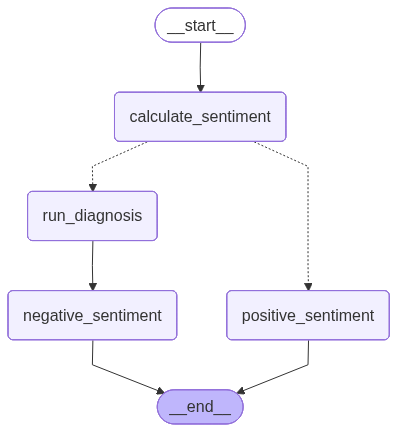

In [97]:
workflow

In [70]:
initial_state = {'review':"""Monster makes a wide array of cables, including some that are very high end. 
                 I initially purchased a pair ofMonster Rock Instrument Cable - 21 Feet - Angled to Straight 1/4-Inch 
                 plugto use with my keyboards, but when it came time to purchase cables for my bass and guitar I 
                 thought I'd pinch a few pennies.  I am so glad I did.I compared this cable model to the more 
                 expensive models I previously purchased and, aside from looks, could not detect any difference in sound. 
                 I Swapped back and forth between my guitars and keyboards, ensuring that each model was used on each 
                 instrument - still no difference.What the more expensive model has going for it is looks. I am not sure 
                 it (the higher priced model) is even more sturdy because the molded stress relief ends on this model seem 
                 to make it more reliable than its pricier sibling.Bottom line: carefully compare both cables using your 
                 own instrument and amp - if possible - before making a purchase decision. You may find, as I did, that 
                 higher price does not necessarily equal higher value, even from the same manufacturer."""
}

In [98]:
initial_state = {'review':"""It hums, crackles, and I think I'm having problems with my equipment.  
As soon as I use any of my other cords then the problem is gone.  
Hosa makes some other products that have good value.  
But based on my experience I don't recommend this one."""}

In [99]:
workflow.invoke(initial_state)

{'review': "It hums, crackles, and I think I'm having problems with my equipment.  \nAs soon as I use any of my other cords then the problem is gone.  \nHosa makes some other products that have good value.  \nBut based on my experience I don't recommend this one.",
 'sentiment': 'negative',
 'response': '"Replace the faulty cable and consider Hosa\'s other products for reliable alternatives."',
 'diagnosis': {'urgency': 'Medium',
  'issue_type': 'Technical malfunction / compatibility issue',
  'tone': 'Negative but constructive'}}